In [1]:
%load_ext autoreload
%autoreload 2

import data_formater69 as df
import calib69 as calib
var_liste = ['M_D', 'M_F', 'Y', 'C', 'G', 'X', 'I', 'P', 'L', 'w', 'K', 'P_I', 'P_F', 'P_D', 'P_T','tau']

#removing first year (1966) in L for all sectors
df.L = df.L.loc[df.L.index.get_level_values('TID') >= 1967]
df.w = df.w.loc[df.w.index.get_level_values('TID') >= 1967]
df.K = df.K.loc[df.K.index.get_level_values('TID') >= 1967]
df.K = df.K.loc[df.K.index.get_level_values('TID') <= 2022]
df.P_I = df.P_I.loc[df.P_I.index.get_level_values('TID') <= 2022]
#data for told findes først fra 2004

# Dimentions check
for var_navn in var_liste:
    obj = getattr(df, var_navn)
    print(f"{var_navn:4} -> Dimensioner: {obj.shape}")

# Eksempel: Se import af landbrugsvarer (j) til mejerier (i) over tid (t)
import_landbrug_til_mejerier = df.M_F.loc['10120', '01000', slice(None)]
import_landbrug_til_mejerier
df

M_D  -> Dimensioner: (504, 1)
M_F  -> Dimensioner: (504, 1)
Y    -> Dimensioner: (168, 1)
C    -> Dimensioner: (168, 1)
G    -> Dimensioner: (168, 1)
X    -> Dimensioner: (168, 1)
I    -> Dimensioner: (90, 1)
P    -> Dimensioner: (168, 1)
L    -> Dimensioner: (168, 1)
w    -> Dimensioner: (168, 1)
K    -> Dimensioner: (168, 1)
P_I  -> Dimensioner: (93, 1)
P_F  -> Dimensioner: (504, 1)
P_D  -> Dimensioner: (504, 1)
P_T  -> Dimensioner: (171, 1)
tau  -> Dimensioner: (504, 1)


<module 'data_formater69' from 'p:\\carhed\\LF27\\LandbrugHistorieKalibrering\\Data\\Indlæsning af data\\data_formater69.py'>

### Afskrivningsrate
$$\delta_{it} =\frac{K_{i,t-1}-K_{it}+I_{it}}{K_{i,t-1}}$$

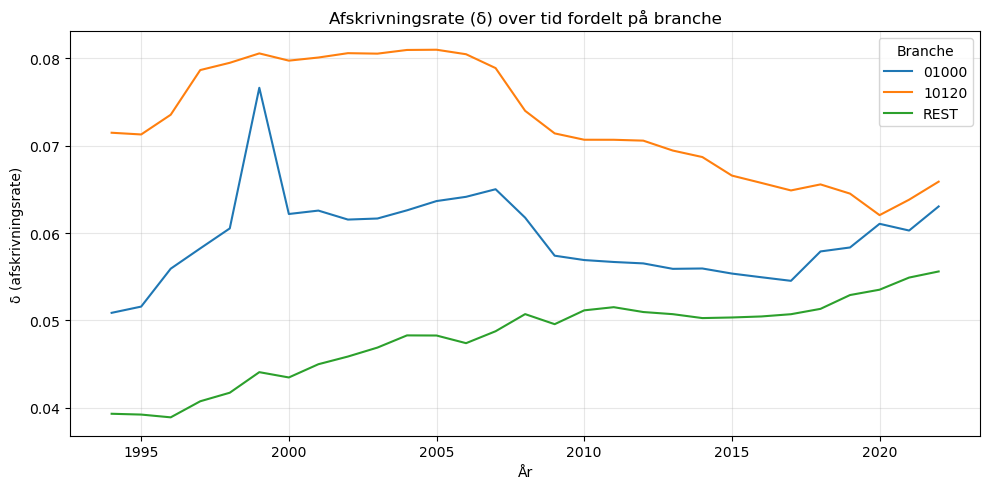

In [2]:
import matplotlib.pyplot as plt

# Kun 1993 og frem
d = calib.delta.loc[(slice(None), slice(1994, 2022))].copy()

# Gør den "wide": år som index, branche som kolonner
d_wide = d.unstack('ANVENDELSE').sort_index()

# Plot
plt.figure(figsize=(10, 5))
for branche in d_wide.columns:
    plt.plot(d_wide.index, d_wide[branche], label=branche)

plt.xlabel("År")
plt.ylabel("δ (afskrivningsrate)")
plt.title("Afskrivningsrate (δ) over tid fordelt på branche")
plt.legend(title="Branche")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
calib.K_prev 
# df.K['Xt'] 
# df.I['Xt']
# delta__ = (calib.K_prev - df.K['Xt'] + df.I['Xt']) / calib.K_prev
# delta__

ANVENDELSE  TID 
01000       1967             NaN
            1968    2.245145e+05
            1969    2.243665e+05
            1970    2.251768e+05
            1971    2.256169e+05
                        ...     
REST        2020    7.209887e+06
            2021    7.326042e+06
            2022    7.489113e+06
            2023    7.648995e+06
            2024    7.786056e+06
Name: Xt, Length: 174, dtype: float64

In [4]:
df.K['Xt']

ANVENDELSE  TID 
01000       1967    2.245145e+05
            1968    2.243665e+05
            1969    2.251768e+05
            1970    2.256169e+05
            1971    2.264702e+05
                        ...     
REST        2018    7.106985e+06
            2019    7.209887e+06
            2020    7.326042e+06
            2021    7.489113e+06
            2022    7.648995e+06
Name: Xt, Length: 168, dtype: float64

In [5]:
# import calib69 as calib
# df.P_I

# calib.delta
# df.w['TIMELOEN_KR']
# df.L['TIMER']
df.K['Xt']
df.Y['Xt']
# df.P_I
# calib.P_KLxKL
calib.P_MxM
# calib.P_O
calib.markup
# # calib.P_K
# xx=calib.P_K*df.K['INDHOLD']
# xx
# df.Y
# df.P_D
# calib.P_K
# df.K

ANVENDELSE  TID 
01000       1966         NaN
            1967         NaN
            1968         NaN
            1969         NaN
            1970         NaN
                      ...   
REST        2020    0.038478
            2021    0.072114
            2022    0.105825
            2023         NaN
            2024         NaN
Length: 177, dtype: float64